In [1]:
import requests

In [2]:
from bs4 import BeautifulSoup

In [3]:
import pandas as pd

In [4]:
url="https://books.toscrape.com/"

In [5]:
response = requests.get(url)

In [6]:
soup=BeautifulSoup(response.text,'html.parser')

In [7]:
books=soup.find_all('article',class_='product_pod')

In [8]:
data=[]

In [9]:
for book in books:
    title=book.h3.a['title']
    price=book.find('p',class_='price_color').text
    rating=book.p['class'][1]
    data.append({
        'Title':title,
        'Price':price,
        'Rating':rating
    })

In [10]:
df=pd.DataFrame(data)

In [11]:
df.to_csv("books_data.csv",index=False)

In [12]:
print(df.head())

                                   Title    Price Rating
0                   A Light in the Attic  Â£51.77  Three
1                     Tipping the Velvet  Â£53.74    One
2                             Soumission  Â£50.10    One
3                          Sharp Objects  Â£47.82   Four
4  Sapiens: A Brief History of Humankind  Â£54.23   Five


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   20 non-null     object
 1   Price   20 non-null     object
 2   Rating  20 non-null     object
dtypes: object(3)
memory usage: 612.0+ bytes


In [14]:
df.describe()

,Title,Price,Rating
count,20,20,20
unique,20,20,5
top,A Light in the Attic,Â£51.77,One
freq,1,1,6


In [15]:
df.isnull().sum()

Title     0
Price     0
Rating    0
dtype: int64

In [16]:
df['Price']=df['Price'].str.replace('£','',regex=False)
df['Price']=df['Price'].str.strip()
df['Price']=pd.to_numeric(df['Price'],errors='coerce')

In [17]:
print(df[df['Price'].isna()])

                                                Title  Price Rating
0                                A Light in the Attic    NaN  Three
1                                  Tipping the Velvet    NaN    One
2                                          Soumission    NaN    One
3                                       Sharp Objects    NaN   Four
4               Sapiens: A Brief History of Humankind    NaN   Five
5                                     The Requiem Red    NaN    One
6   The Dirty Little Secrets of Getting Your Dream...    NaN   Four
7   The Coming Woman: A Novel Based on the Life of...    NaN  Three
8   The Boys in the Boat: Nine Americans and Their...    NaN   Four
9                                     The Black Maria    NaN    One
10     Starving Hearts (Triangular Trade Trilogy, #1)    NaN    Two
11                              Shakespeare's Sonnets    NaN   Four
12                                        Set Me Free    NaN   Five
13  Scott Pilgrim's Precious Little Life (Scott 

In [18]:
df['Price']=df['Price'].fillna(df['Price'].mean())

In [19]:
print(f"Average Price {df['Price'].mean()}")
print(f"Max Price {df['Price'].max()}")
print(f"Rating Count {df['Price'].value_counts()}")

Average Price nan
Max Price nan
Rating Count Series([], Name: count, dtype: int64)


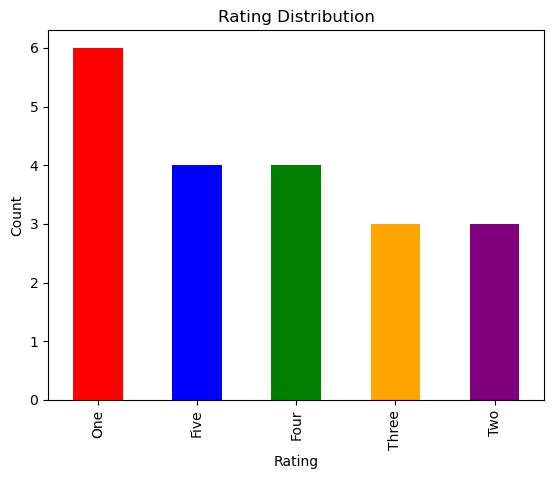

In [20]:
import matplotlib.pyplot as plt
df['Rating'].value_counts().plot(kind='bar',color=['red','blue','green','orange','purple'])
plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()

In [21]:
Y=df.iloc[:,-1].values
X=df.iloc[:, 1:-1].values

In [22]:
X.shape

(20, 1)

In [23]:
Y.shape

(20,)

In [24]:
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,random_state=42,test_size=0.25)

In [28]:
from sklearn.tree import DecisionTreeClassifier
DTC=DecisionTreeClassifier(criterion='gini',random_state=0)
DTC.fit(X_train,Y_train)
Y_pred=DTC.predict(X_test)

In [29]:
from sklearn.metrics import accuracy_score
print(accuracy_score(Y_pred,Y_test))

0.0


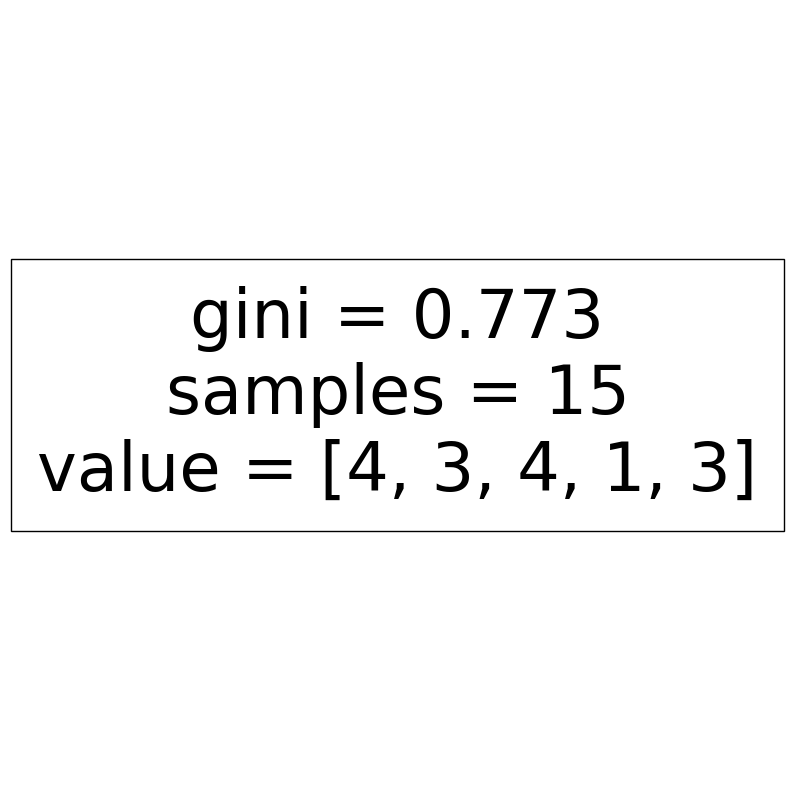

In [30]:
from sklearn import tree
plt.figure(figsize=(10,10))
tree.plot_tree(DTC.fit(X_train,Y_train))
plt.show()

In [31]:
DTC_entropy= DecisionTreeClassifier(criterion='entropy',max_depth=3,random_state=0)
DTC_entropy.fit(X_train,Y_train)
Y_pred_entropy=DTC.predict(X_test)

0.0


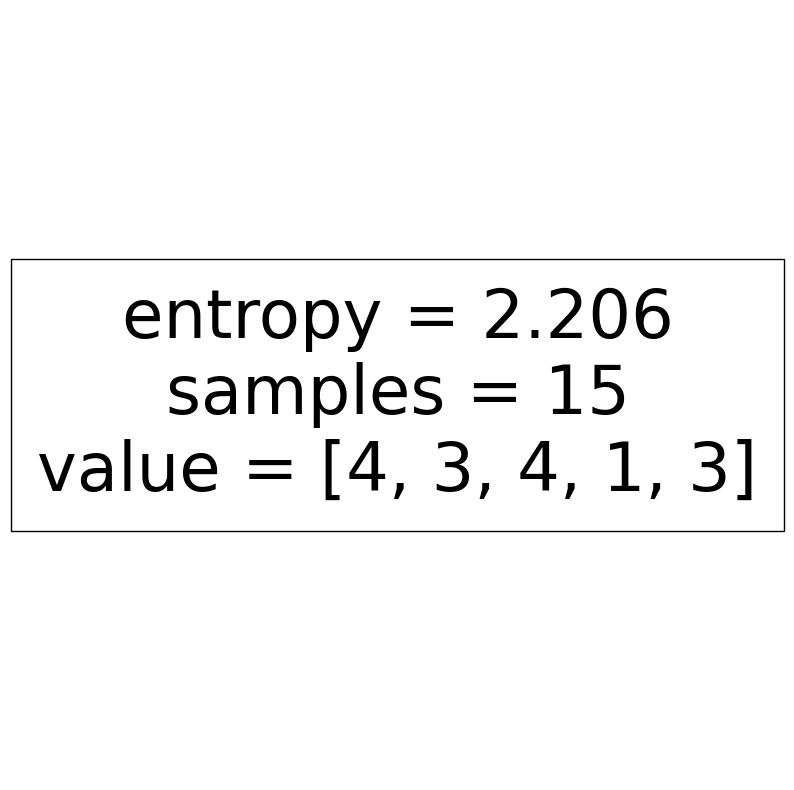

In [32]:
print(accuracy_score(Y_test,Y_pred_entropy))
plt.figure(figsize=(10,10))
tree.plot_tree(DTC_entropy.fit(X_train,Y_train))
plt.show()